In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from tqdm import tqdm
from sklearn.datasets import load_files
from pyvi import ViTokenizer
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd  

%matplotlib inline


In [2]:
data_array = np.genfromtxt('german.data-numeric')
data_frame = pd.DataFrame(data_array, columns = ['A' + str(i) for i in range(1, 25)] + ['target'])
data_frame

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A16,A17,A18,A19,A20,A21,A22,A23,A24,target
0,1.0,6.0,4.0,12.0,5.0,5.0,3.0,4.0,1.0,67.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,2.0,48.0,2.0,60.0,1.0,3.0,2.0,2.0,1.0,22.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0
2,4.0,12.0,4.0,21.0,1.0,4.0,3.0,3.0,1.0,49.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,1.0,42.0,2.0,79.0,1.0,4.0,3.0,4.0,2.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,24.0,3.0,49.0,1.0,3.0,3.0,4.0,4.0,53.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,4.0,12.0,2.0,17.0,1.0,4.0,2.0,4.0,1.0,31.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
996,1.0,30.0,2.0,39.0,1.0,3.0,1.0,4.0,2.0,40.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
997,4.0,12.0,2.0,8.0,1.0,5.0,3.0,4.0,3.0,38.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
998,1.0,45.0,2.0,18.0,1.0,3.0,3.0,4.0,4.0,23.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0


In [3]:
X,y = data_frame.drop('target', axis=1), data_frame['target']
y = 1 - (y - 1)
y

0      1.0
1      0.0
2      1.0
3      1.0
4      0.0
      ... 
995    1.0
996    1.0
997    1.0
998    0.0
999    1.0
Name: target, Length: 1000, dtype: float64

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((800, 24), (800,), (200, 24), (200,))

In [5]:
def neg_cost(estimator, X, y):
    y_true = y
    y_pred = estimator.predict(X)
    true_pos = ((y_true==y_pred)&(y_true==1.0))*0.0
    true_ne = ((y_true==y_pred)&(y_true==0.0))*0.0
    false_ne = ((y_true!=y_pred)&(y_true==1.0))*1.0
    false_pos = ((y_true!=y_pred)&(y_true==0.0))*5.0
    return -sum(true_pos + true_ne + false_pos + false_ne)/len(y_true)


In [6]:
def plot(title, xlabel, X, Y, ylabel = "neg_cost"):
    plt.xlabel(xlabel)
    plt.title(title)
    plt.grid()
    plt.ylabel(ylabel)
    plt.plot(X, Y, marker='o')

os.makedirs("images2",exist_ok=True) 

100%|██████████| 4/4 [00:00<00:00,  7.21it/s]


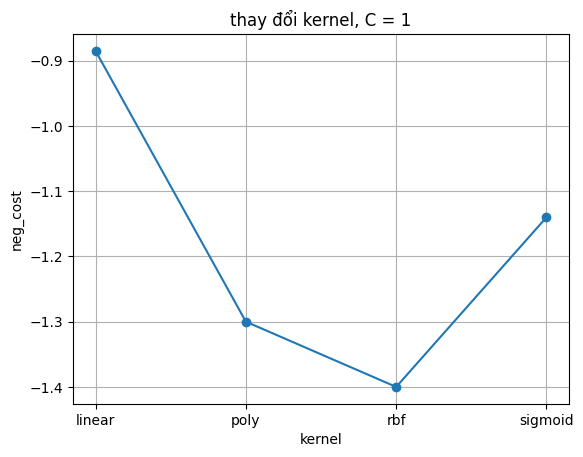

In [7]:
title = "thay đổi kernel, C = 1"
xlabel = "kernel"
X = []
Y = []
error = []
for kernel in tqdm(['linear', 'poly', 'rbf', 'sigmoid']):
    # Với mỗi kernel được chọn,
    # thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = svm.SVC(kernel=kernel, C=1.0)
    text_clf.fit(X_train, y_train)
    cost = neg_cost(text_clf, X_test, y_test)
    X.append(kernel)
    Y.append(cost)
# lưu kết quả ra file ảnh
plot(title, xlabel, X, Y)
plt.savefig('images2/svm_change_kernel.png', bbox_inches='tight')
plt.show()

100%|██████████| 4/4 [00:53<00:00, 13.27s/it]


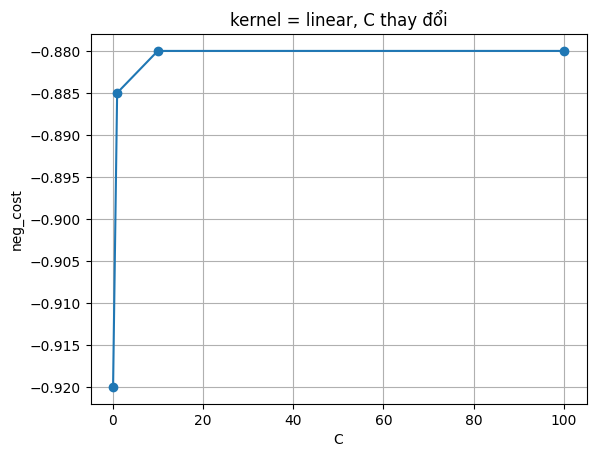

In [8]:
title = "kernel = linear, C thay đổi"
xlabel = "C"
X = []
Y = []
error = []
for C in tqdm([0.1, 1, 10, 100]):
    # Với mỗi giá trị C được chọn,
    # thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = svm.SVC(kernel='linear', C=C)
    text_clf.fit(X_train, y_train)
    cost = neg_cost(text_clf, X_test, y_test)
    X.append(C)
    Y.append(cost)
# lưu kết quả ra file ảnh
plot(title, xlabel, X, Y)
plt.savefig('images2/svm_change_C.png', bbox_inches='tight')
plt.show()

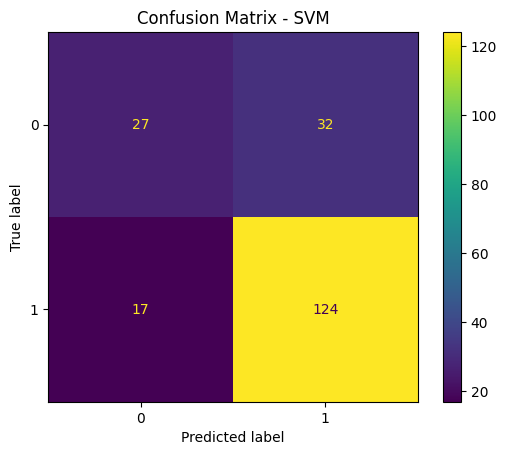

In [9]:
model_svm = svm.SVC(kernel='linear', C=1.0)
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot()
plt.title("Confusion Matrix - SVM")
plt.savefig('images2/svm_confusion_matrix.png', bbox_inches='tight')
plt.show()

100%|██████████| 2/2 [00:00<00:00, 10.69it/s]


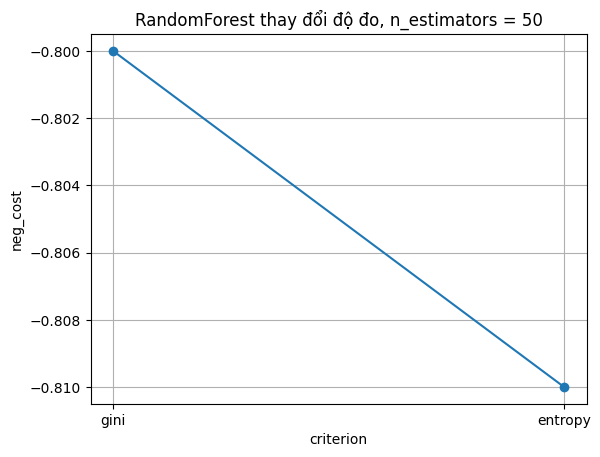

In [10]:
title = "RandomForest thay đổi độ đo, n_estimators = 50"
X = []
y = []

for criterion in tqdm(['gini', 'entropy']):
    model_rf = RandomForestClassifier(n_estimators=50, criterion=criterion, random_state=42)
    model_rf.fit(X_train, y_train)
    cost = neg_cost(model_rf, X_test, y_test)
    X.append(criterion)
    y.append(cost)
plot(title, "criterion", X, y)
plt.savefig('images2/rf_change_criterion.png', bbox_inches='tight')
plt.show()

100%|██████████| 4/4 [00:00<00:00,  6.15it/s]


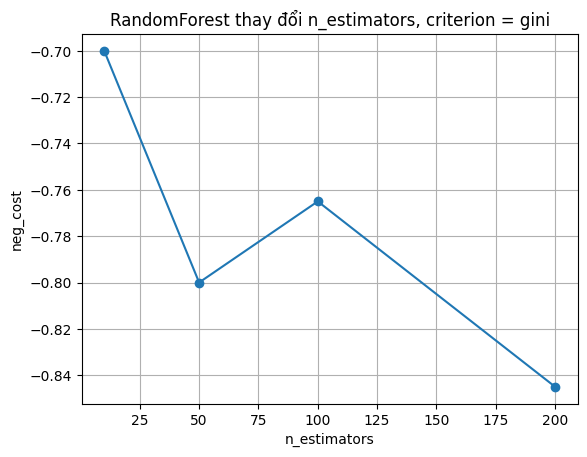

In [11]:
title = "RandomForest thay đổi n_estimators, criterion = gini"

X = []
y = []

for n_estimators in tqdm([10, 50, 100, 200]):
    model_rf = RandomForestClassifier(n_estimators=n_estimators, criterion='gini', random_state=42)
    model_rf.fit(X_train, y_train)
    cost = neg_cost(model_rf, X_test, y_test)
    X.append(n_estimators)
    y.append(cost)
plot(title, "n_estimators", X, y)
plt.savefig('images2/rf_change_n_estimators.png', bbox_inches='tight')
plt.show()

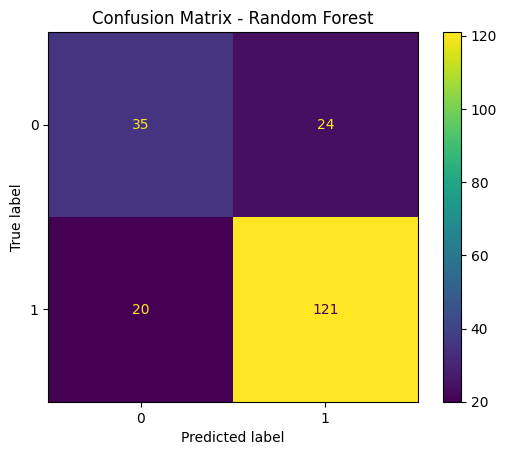

In [12]:
model_rf = RandomForestClassifier(n_estimators=10, criterion='gini', random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.savefig('images2/rf_confusion_matrix.png', bbox_inches='tight')
plt.show()

100%|██████████| 5/5 [00:02<00:00,  1.74it/s]


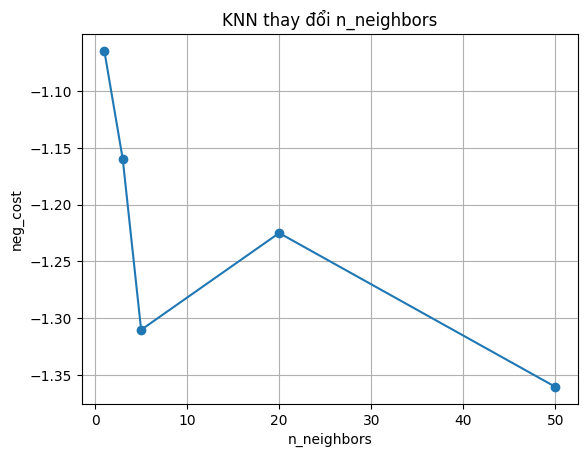

In [13]:
from sklearn.neighbors import KNeighborsClassifier
title = "KNN thay đổi n_neighbors"
X = []
y = []

for k in tqdm([1, 3, 5, 20, 50]):
    model_knn = KNeighborsClassifier(n_neighbors=k)
    model_knn.fit(X_train, y_train)
    cost = neg_cost(model_knn, X_test, y_test)
    X.append(k)
    y.append(cost)

plot(title, "n_neighbors", X, y)
plt.savefig('images2/knn_change_n_neighbors.png', bbox_inches='tight')
plt.show()

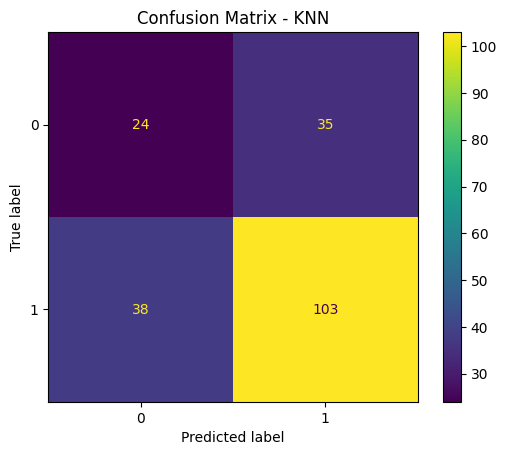

In [15]:
model_knn = KNeighborsClassifier(n_neighbors=1)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot()
plt.title("Confusion Matrix - KNN")
plt.savefig('images2/knn_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [17]:
print(f"SVM cost: {neg_cost(model_svm, X_test, y_test):.4f}")
print(f"Random Forest cost: {neg_cost(model_rf, X_test, y_test):.4f}")
print(f"KNN cost: {neg_cost(model_knn, X_test, y_test):.4f}")

SVM cost: -0.8850
Random Forest cost: -0.7000
KNN cost: -1.0650
